In [25]:
import pandas as pd
import numpy as np
import re
import pycountry
import matplotlib.pyplot as plt
import seaborn as sns

# import the data file
df_Data = pd.read_excel(
    r"D:\Projects\Data\Countries_Socioeconom_Profiles_Data\World_Development_Indicators.xlsx",
    sheet_name=0
)

# replace .. with nans
df_Data = df_Data.replace("..", np.nan)

# drop years with high persentage of nans
df_Data = df_Data.drop(columns=['2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]'])

# Year columns
year_cols = [f"{year} [YR{year}]" for year in range(2010, 2022)]

df_Data = df_Data.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

# Extract only the year
df_Data["Year"] = df_Data["Year"].str.extract(r"(\d{4})").astype(int)

# Make values numeric
df_Data["Value"] = pd.to_numeric(df_Data["Value"], errors="coerce")

# pivot df_Data
df_wide = df_Data.pivot(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

# normalize the names
df_wide.columns = (
    df_wide.columns
    .str.lower()
    .str.strip()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)

rename_dict = {
    "Country Name": "country_name",
    "Country Code": "country_code",
    "Year": "year",
    
    "Access to electricity (% of population)": "access_to_electricity",
    "Agriculture, forestry, and fishing, value added (% of GDP)": "agriculture_value_added",
    "Broad money (% of GDP)": "broad_money",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)": "co2_emissions_per_capita",
    "Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP)": "carbon_intensity_gdp",
    "Central government debt, total (% of GDP)": "government_debt",
    "Current health expenditure (% of GDP)": "health_expenditure",
    "Domestic credit to private sector (% of GDP)": "domestic_credit_private_sector",
    "Energy use (kg of oil equivalent per capita)": "energy_use_per_capita",
    "Exports of goods and services (% of GDP)": "exports",
    "Fertility rate, total (births per woman)": "fertility_rate",
    "Foreign direct investment, net inflows (% of GDP)": "fdi_inflows",
    "Forest area (% of land area)": "forest_area",
    "Fossil fuel energy consumption (% of total)": "fossil_fuel_consumption",
    "GDP growth (annual %)": "gdp_growth",
    "GDP per capita (constant 2015 US$)": "gdp_per_capita",
    "Gross capital formation (% of GDP)": "gross_capital_formation",
    "Imports of goods and services (% of GDP)": "imports",
    "Individuals using the Internet (% of population)": "internet_usage",
    "Industry (including construction), value added (% of GDP)": "industry_value_added",
    "Inflation, consumer prices (annual %)": "inflation",
    "Life expectancy at birth, total (years)": "life_expectancy",
    "Literacy rate, adult total (% of people ages 15 and above)": "literacy_rate",
    "Military expenditure (% of general government expenditure)": "military_expenditure",
    "Multidimensional poverty headcount ratio (World Bank) (% of population)": "multidimensional_poverty",
    "Population growth (annual %)": "population_growth",
    "Renewable electricity output (% of total electricity output)": "renewable_electricity",
    "Renewable energy consumption (% of total final energy consumption)": "renewable_energy",
    "Research and development expenditure (% of GDP)": "rd_expenditure",
    "School enrollment, primary (% gross)": "primary_school_enrollment",
    "Services, value added (% of GDP)": "services_value_added",
    "Trade (% of GDP)": "trade",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)": "unemployment",
    "Urban population (% of total population)": "urban_population"
}

df_wide = df_wide.rename(columns=rename_dict)

# Retain only actual countries with valid ISO 3166-1 alpha-3 codes
valid_iso_codes = {country.alpha_3 for country in pycountry.countries}
df_countries = df_wide[df_wide['country_code'].isin(valid_iso_codes)].copy()

# calculate each country's overall percentage of missing data across all indicators and orders them from highest missingness to lowest.
feature_cols = df_countries.columns.difference(
    ["country_name", "country_code", "year"]
)

df_country_nan = (
    df_countries.groupby(["country_name", "country_code"])[feature_cols]
    .apply(lambda x: x.isna().sum().sum())
    .rename("nan_count")
    .reset_index()
)

# Total possible values per country
df_country_nan["total_values"] = (
    df_countries.groupby(["country_name", "country_code"])
    .size()
    .values * len(feature_cols)
)

# Percentage of missing values
df_country_nan["nan_percentage"] = (
    df_country_nan["nan_count"] /
    df_country_nan["total_values"]
)

df_country_nan = df_country_nan.sort_values(
    "nan_percentage",
    ascending=False
)

# delete country's with high persentage of nans
nan_per_delete = df_country_nan['nan_percentage'].quantile(q= 0.85)
country_to_delete = df_country_nan[df_country_nan['nan_percentage'] >= nan_per_delete]
country_to_delete_list = country_to_delete['country_name'].tolist()



# delete columns with high nans
nan_summary = (
    pd.DataFrame({
        "nan_count": df_countries.isna().sum(),
        "nan_percentage": df_countries.isna().mean()
    })
    .reset_index(names="Series Name")
    .sort_values("nan_percentage", ascending=False)
)

for country in country_to_delete_list:

    df_countries = df_countries[df_countries['country_name'] != country]

null_per_max = 0.5

Series_Name_delete = nan_summary[nan_summary['nan_percentage'] >= null_per_max]
Series_Name_delete_list = Series_Name_delete['Series Name'].tolist()
df_countries = df_countries.drop(columns=Series_Name_delete_list)

In [26]:
df_countries.loc[
    df_countries["fossil_fuel_energy_consumption_of_total"] < 0,
    "fossil_fuel_energy_consumption_of_total"
] = np.nan

df_countries.loc[
    df_countries["gross_capital_formation_of_gdp"] < 0,
    "gross_capital_formation_of_gdp"
] = np.nan

In [27]:
df_countries.drop(columns=['exports_of_goods_and_services_of_gdp', 'imports_of_goods_and_services_of_gdp'], inplace=True)

In [28]:
df_countries['trade_of_gdp_log'] = np.log1p(df_countries['trade_of_gdp'])
df_countries.drop(columns=['trade_of_gdp'], inplace=True)

In [29]:
index_components = [
    "access_to_electricity_of_population",
    "individuals_using_the_internet_of_population",
    "life_expectancy_at_birth_total_years",
    "urban_population_of_total_population"
]

internet_col = "individuals_using_the_internet_of_population"

# 1. Country-level mean
df_countries[internet_col] = (
    df_countries[internet_col]
    .fillna(
        df_countries.groupby("country_code")[internet_col]
        .transform("mean")
    )
)

# 2. Year-level mean for countries with no Internet observations
df_countries[internet_col] = (
    df_countries[internet_col]
    .fillna(
        df_countries.groupby("year")[internet_col]
        .transform("mean")
    )
)

# 3. Global mean as absolute last fallback
df_countries[internet_col] = (
    df_countries[internet_col]
    .fillna(df_countries[internet_col].mean())
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_countries[
    [f"{col}_z" for col in index_components]
] = scaler.fit_transform(
    df_countries[index_components]
)

df_countries["Socioeconomic_developmen_Index"] = (
    df_countries[[f"{col}_z" for col in index_components]]
    .mean(axis=1)
)

In [30]:
df_countries.drop(columns=[
    "access_to_electricity_of_population",
    "individuals_using_the_internet_of_population",
    "life_expectancy_at_birth_total_years",
    "urban_population_of_total_population",
    'individuals_using_the_internet_of_population_z',
    'life_expectancy_at_birth_total_years_z',
    'urban_population_of_total_population_z',
    'access_to_electricity_of_population_z'
], inplace=True)

In [31]:
energy_cols = [
    "energy_use_kg_of_oil_equivalent_per_capita",
    "carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita"
]


# 1. Country-level mean
df_countries[energy_cols] = (
    df_countries[energy_cols]
    .fillna(
        df_countries.groupby("country_code")[energy_cols]
        .transform("mean")
    )
)

# 2. Year-level mean for countries with no Internet observations
df_countries[energy_cols] = (
    df_countries[energy_cols]
    .fillna(
        df_countries.groupby("year")[energy_cols]
        .transform("mean")
    )
)

# 3. Global mean as absolute last fallback
df_countries[energy_cols] = (
    df_countries[energy_cols]
    .fillna(df_countries[energy_cols].mean())
)


# 4. LOG TRANSFORMATION

df_log = np.log1p(df_countries[energy_cols])


# 5. STANDARDIZATION
scaler = StandardScaler()
z_cols = [f"{col}_z" for col in energy_cols]
df_countries[z_cols] = scaler.fit_transform(df_log)


# 6. CREATE ENERGY & ENVIRONMENTAL INDEX
df_countries["Energy_Environmental_Index"] = (
    df_countries[z_cols].mean(axis=1)
)


# 7. DROP ORIGINAL COMPONENTS
df_countries.drop(columns=energy_cols, inplace=True)
df_countries.drop(columns=['energy_use_kg_of_oil_equivalent_per_capita_z', 'carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita_z'], inplace=True)

In [32]:
df_countries['domestic_credit_to_private_sector_of_gdp_log'] = np.log1p(df_countries['domestic_credit_to_private_sector_of_gdp'])
df_countries.drop(columns= 'domestic_credit_to_private_sector_of_gdp', inplace=True)

In [33]:
fdi = df_countries['foreign_direct_investment_net_inflows_of_gdp']

df_countries['fdi_log'] = np.sign(fdi) * np.log1p(np.abs(fdi))
df_countries.drop(columns='foreign_direct_investment_net_inflows_of_gdp', inplace=True)

In [34]:
inflation = df_countries['inflation_consumer_prices_annual_']

df_countries['inflation_log'] = (np.sign(inflation)* np.log1p(np.abs(inflation)))
df_countries.drop(columns='inflation_consumer_prices_annual_', inplace=True)

In [35]:
df_countries['broad_money_of_gdp_log'] = np.log1p(df_countries['broad_money_of_gdp'])
df_countries.drop(columns='broad_money_of_gdp', inplace=True)

In [36]:
df_countries['gdp_per_capita_constant_2015_us_log'] = np.log1p(df_countries['gdp_per_capita_constant_2015_us'])
df_countries.drop(columns='gdp_per_capita_constant_2015_us', inplace=True)

In [37]:
df_countries['military_expenditure_of_general_government_expenditure_log'] = np.log1p(df_countries['military_expenditure_of_general_government_expenditure'])
df_countries.drop(columns='military_expenditure_of_general_government_expenditure', inplace=True)

### **What is new**

In [38]:
# Select only years 2010–2021
df_2010_2021 = df_countries[
    df_countries["year"].between(2010, 2021)
].copy()

indicator_cols = [
    col for col in df_countries.columns
    if col not in ["country_name", "country_code", "year"]
]

n_years = df_2010_2021["year"].nunique()
n_countries = df_2010_2021["country_name"].nunique()

# 1. Calculate total null count per country for each indicator
# Resulting shape: (n_countries, n_indicators)
country_nulls = df_2010_2021.groupby("country_name")[indicator_cols].apply(lambda x: x.isna().sum())

summary_rows = []

for col in indicator_cols:
    null_counts = country_nulls[col]
    
    # Base indicators tracking
    totally_null = (null_counts == n_years).sum()
    total_nulls_totally_null = totally_null * n_years
    
    partially_null = ((null_counts > 0) & (null_counts < n_years)).sum()
    total_nulls_partially_null = null_counts[null_counts < n_years].sum()
    
    total_nulls = null_counts.sum()
    
    row_dict = {
        "null_percentage": (total_nulls / (n_countries * n_years)) * 100,
        "indicator": col,
        "total_null_values": total_nulls
    }
    
    # 2. Add dynamic breakdown columns for countries missing 1, 2, ..., n_years
    for k in range(1, n_years + 1):
        countries_with_k_nulls = (null_counts == k).sum()
        row_dict[f"countries_with_{k}_nulls"] = countries_with_k_nulls
        row_dict[f"nulls_from_{k}_null_countries"] = countries_with_k_nulls * k
        
    summary_rows.append(row_dict)

# Convert to DataFrame
summary = pd.DataFrame(summary_rows)

# Sort by missing percentage
summary = summary.sort_values("null_percentage", ascending=False).reset_index(drop=True)

summary

,null_percentage,indicator,total_null_values,countries_with_1_nulls,nulls_from_1_null_countries,countries_with_2_nulls,nulls_from_2_null_countries,countries_with_3_nulls,nulls_from_3_null_countries,countries_with_4_nulls,...,countries_with_8_nulls,nulls_from_8_null_countries,countries_with_9_nulls,nulls_from_9_null_countries,countries_with_10_nulls,nulls_from_10_null_countries,countries_with_11_nulls,nulls_from_11_null_countries,countries_with_12_nulls,nulls_from_12_null_countries
0,22.985348,fossil_fuel_energy_consumption_of_total,502,8,8,3,6,4,12,0,...,0,0,0,0,0,0,0,0,38,456
1,19.871795,military_expenditure_of_general_government_exp...,434,3,3,5,10,3,9,2,...,1,8,1,9,1,10,2,22,28,336
2,18.452381,broad_money_of_gdp_log,403,6,6,7,14,2,6,3,...,2,16,0,0,1,10,1,11,26,312
3,15.293040,school_enrollment_primary_gross,334,22,22,20,40,8,24,6,...,5,40,1,9,1,10,4,44,3,36
4,10.714286,gross_capital_formation_of_gdp,234,0,0,0,0,2,6,1,...,0,0,0,0,1,10,1,11,15,180
5,9.157509,trade_of_gdp_log,200,1,1,0,0,3,9,2,...,0,0,0,0,1,10,1,11,12,144
6,8.699634,domestic_credit_to_private_sector_of_gdp_log,190,7,7,9,18,1,3,3,...,2,16,0,0,1,10,1,11,5,60
7,3.067766,inflation_log,67,1,1,6,12,0,0,0,...,1,8,0,0,0,0,0,0,2,24
8,3.067766,renewable_electricity_output_of_total_electric...,67,2,2,3,6,2,6,1,...,0,0,0,0,1,10,1,11,1,12
9,2.747253,unemployment_total_of_total_labor_force_modele...,60,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,5,60


In [39]:
# Years to analyze
years = list(range(2010, 2022))

# Indicator columns
indicator_cols = [
    col for col in df_countries.columns
    if col not in ["country_name", "country_code", "year"]
]

# Keep only 2010–2021
df_10_21 = df_countries[
    df_countries["year"].isin(years)
].copy()

# Check whether each indicator is completely NULL
# for each country across all 12 years
fully_null_by_country = (
    df_10_21
    .groupby(["country_name", "country_code"])[indicator_cols]
    .apply(lambda x: x.isna().all())
)

# Get the actual indicator names that are completely NULL
country_null_summary = (
    fully_null_by_country
    .apply(lambda row: row[row].index.tolist(), axis=1)
    .reset_index(name="fully_null_indicators")
)

# Count them
country_null_summary["fully_null_count"] = (
    country_null_summary["fully_null_indicators"].str.len()
)

# Percentage
country_null_summary["fully_null_percentage"] = (
    country_null_summary["fully_null_count"]
    / len(indicator_cols)
    * 100
)

# Sort from most missing to least missing
country_null_summary = country_null_summary.sort_values(
    "fully_null_count",
    ascending=False
).reset_index(drop=True)

country_null_summary

,country_name,country_code,fully_null_indicators,fully_null_count,fully_null_percentage
0,"Macao SAR, China",MAC,[agriculture_forestry_and_fishing_value_added_...,6,25.000000
1,Cuba,CUB,"[domestic_credit_to_private_sector_of_gdp_log,...",5,20.833333
2,Kiribati,KIR,"[fossil_fuel_energy_consumption_of_total, unem...",5,20.833333
3,Turkmenistan,TKM,"[gross_capital_formation_of_gdp, domestic_cred...",5,20.833333
4,Barbados,BRB,"[fossil_fuel_energy_consumption_of_total, gros...",4,16.666667
...,...,...,...,...,...
177,Uzbekistan,UZB,[],0,0.000000
178,Viet Nam,VNM,[],0,0.000000
179,"Yemen, Rep.",YEM,[],0,0.000000
180,Zambia,ZMB,[],0,0.000000


In [40]:
for _, row in summary.iterrows():
    print(f"\n{row['indicator']}")
    print("-" * 80)
    
    for k in range(1, n_years + 1):
        count = row[f"countries_with_{k}_nulls"]
        
        if count > 0:
            print(f"{k:2} missing years : {'█' * count} ({count} countries)")


fossil_fuel_energy_consumption_of_total
--------------------------------------------------------------------------------
 1 missing years : ████████ (8 countries)
 2 missing years : ███ (3 countries)
 3 missing years : ████ (4 countries)
 5 missing years : ████ (4 countries)
12 missing years : ██████████████████████████████████████ (38 countries)

military_expenditure_of_general_government_expenditure_log
--------------------------------------------------------------------------------
 1 missing years : ███ (3 countries)
 2 missing years : █████ (5 countries)
 3 missing years : ███ (3 countries)
 4 missing years : ██ (2 countries)
 5 missing years : █ (1 countries)
 7 missing years : ██ (2 countries)
 8 missing years : █ (1 countries)
 9 missing years : █ (1 countries)
10 missing years : █ (1 countries)
11 missing years : ██ (2 countries)
12 missing years : ████████████████████████████ (28 countries)

broad_money_of_gdp_log
-------------------------------------------------------------

In [41]:
df_countries.drop(columns=['fossil_fuel_energy_consumption_of_total', 'military_expenditure_of_general_government_expenditure_log', 'broad_money_of_gdp_log', 'gross_capital_formation_of_gdp', 'trade_of_gdp_log', 'domestic_credit_to_private_sector_of_gdp_log'], inplace=True)

In [42]:
indicator_cols = [
    col for col in df_countries.columns
    if col not in ["country_name", "country_code", "year"]
]

# Count total missing values per year
nulls_per_year = (
    df_countries
    .groupby(["year"])[indicator_cols]
    .apply(lambda x: x.isna().sum().sum())
)

nulls_per_year

year
2010    65
2011    61
2012    57
2013    63
2014    57
2015    56
2016    54
2017    63
2018    67
2019    72
2020    76
2021    74
dtype: int64

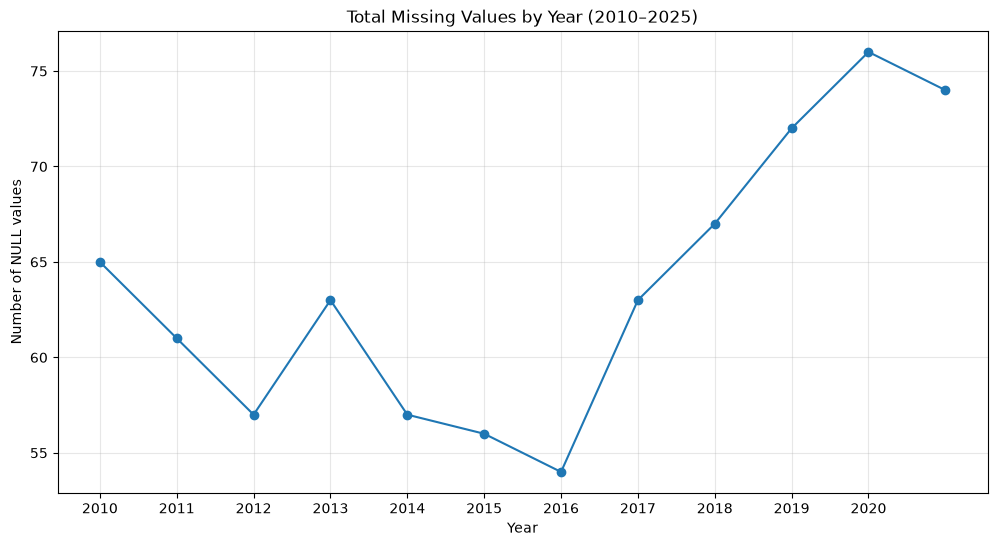

In [43]:
# Indicator columns only
indicator_cols = [
    col for col in df_countries.columns
    if col not in ["country_name", "country_code", "year"]
]

# Count total missing values per year
nulls_per_year = (
    df_countries
    .groupby(["year"])[indicator_cols]
    .apply(lambda x: x.isna().sum().sum())
)

plt.figure(figsize=(12, 6))

plt.plot(
    nulls_per_year.index,
    nulls_per_year.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of NULL values")
plt.title("Total Missing Values by Year (2010–2025)")
plt.xticks(range(2010, 2021))
plt.grid(alpha=0.3)

plt.show()

In [44]:
nan_summary = (
    pd.DataFrame({
        "nan_count": df_countries.isna().sum(),
        "nan_percentage": df_countries.isna().mean()
    })
    .reset_index(names="Series Name")
    .sort_values("nan_percentage", ascending=False)
)

nan_summary

,Series Name,nan_count,nan_percentage
13,school_enrollment_primary_gross,334,0.152930
11,renewable_electricity_output_of_total_electric...,67,0.030678
19,inflation_log,67,0.030678
15,unemployment_total_of_total_labor_force_modele...,60,0.027473
18,fdi_log,45,0.020604
5,current_health_expenditure_of_gdp,45,0.020604
4,carbon_intensity_of_gdp_kg_co2e_per_constant_2...,42,0.019231
3,agriculture_forestry_and_fishing_value_added_o...,30,0.013736
7,forest_area_of_land_area,26,0.011905
14,services_value_added_of_gdp,18,0.008242


In [45]:
cols_with_nulls = df_countries.columns[df_countries.isna().any()].tolist()

for col in cols_with_nulls:

    df_countries[col] = (
        df_countries
        .groupby("country_code")[col]
        .transform(
            lambda x: x.interpolate(
                method="linear",
                limit=3,
                limit_area="inside"
            )
        )
    )

    df_countries[col] = (
        df_countries
        .groupby("country_code")[col]
        .transform(func="median")
        )

    df_countries[col] = (
    df_countries[col]
    .fillna(
        df_countries
        .groupby("year")[col]
        .transform(func="median")
        )
    )


In [46]:
nan_summary = (
    pd.DataFrame({
        "nan_count": df_countries.isna().sum(),
        "nan_percentage": df_countries.isna().mean()
    })
    .reset_index(names="Series Name")
    .sort_values("nan_percentage", ascending=False)
)

nan_summary

,Series Name,nan_count,nan_percentage
0,country_name,0,0.0
1,country_code,0,0.0
2,year,0,0.0
3,agriculture_forestry_and_fishing_value_added_o...,0,0.0
4,carbon_intensity_of_gdp_kg_co2e_per_constant_2...,0,0.0
5,current_health_expenditure_of_gdp,0,0.0
6,fertility_rate_total_births_per_woman,0,0.0
7,forest_area_of_land_area,0,0.0
8,gdp_growth_annual_,0,0.0
9,industry_including_construction_value_added_of...,0,0.0
